# LightGBM Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- LightGBM gradient boosting classifier
- Handles class imbalance with `scale_pos_weight`
- Records training time, scoring time, and model performance

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data & Selected Features

In [2]:
# Load features
features_df = pd.read_csv('features.csv', index_col=0)

# Load selected feature names
with open('selected_features_top50.txt', 'r') as f:
    selected_features = [line.strip() for line in f if line.strip()]

print(f'Total consumers: {features_df.shape[0]}')
print(f'Selected features: {len(selected_features)}')
print(f'Delinquency rate: {features_df["DQ_TARGET"].mean():.2%}')

Total consumers: 12900
Selected features: 50
Delinquency rate: 8.86%


## 2. Prepare Data & Train/Val/Test Split

In [3]:
# Clean and subset
df_clean = features_df[features_df['DQ_TARGET'].notna()].copy()
y = df_clean['DQ_TARGET'].astype(int).values

# Keep only selected features
available_features = [f for f in selected_features if f in df_clean.columns]
X = df_clean[available_features].fillna(0).values

print(f'Features used: {len(available_features)}')
print(f'Samples: {X.shape[0]}')
print(f'Class distribution: 0={np.sum(y==0)}, 1={np.sum(y==1)}')

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: 50/50 of temp -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'\nTrain: {X_train.shape[0]} ({y_train.mean():.2%} positive)')
print(f'Val:   {X_val.shape[0]} ({y_val.mean():.2%} positive)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.2%} positive)')

Features used: 50
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


## 3. Train LightGBM Model

In [4]:
# Class imbalance weight
n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, feature_name=available_features)
val_data = lgb.Dataset(X_val, label=y_val, feature_name=available_features, reference=train_data)

# LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42,
}

# Train with early stopping
print('\nTraining LightGBM...')
training_start_time = time.time()

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
]

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

training_end_time = time.time()
training_time = training_end_time - training_start_time

print(f'\nTraining completed in {training_time:.2f}s')
print(f'Best iteration: {model.best_iteration}')
print(f'Best val AUC: {model.best_score["val"]["auc"]:.4f}')

scale_pos_weight: 10.30

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.972534	val's auc: 0.773919
[100]	train's auc: 0.993553	val's auc: 0.780921
Early stopping, best iteration is:
[87]	train's auc: 0.990313	val's auc: 0.7829

Training completed in 1.12s
Best iteration: 87
Best val AUC: 0.7829


## 4. Feature Importance

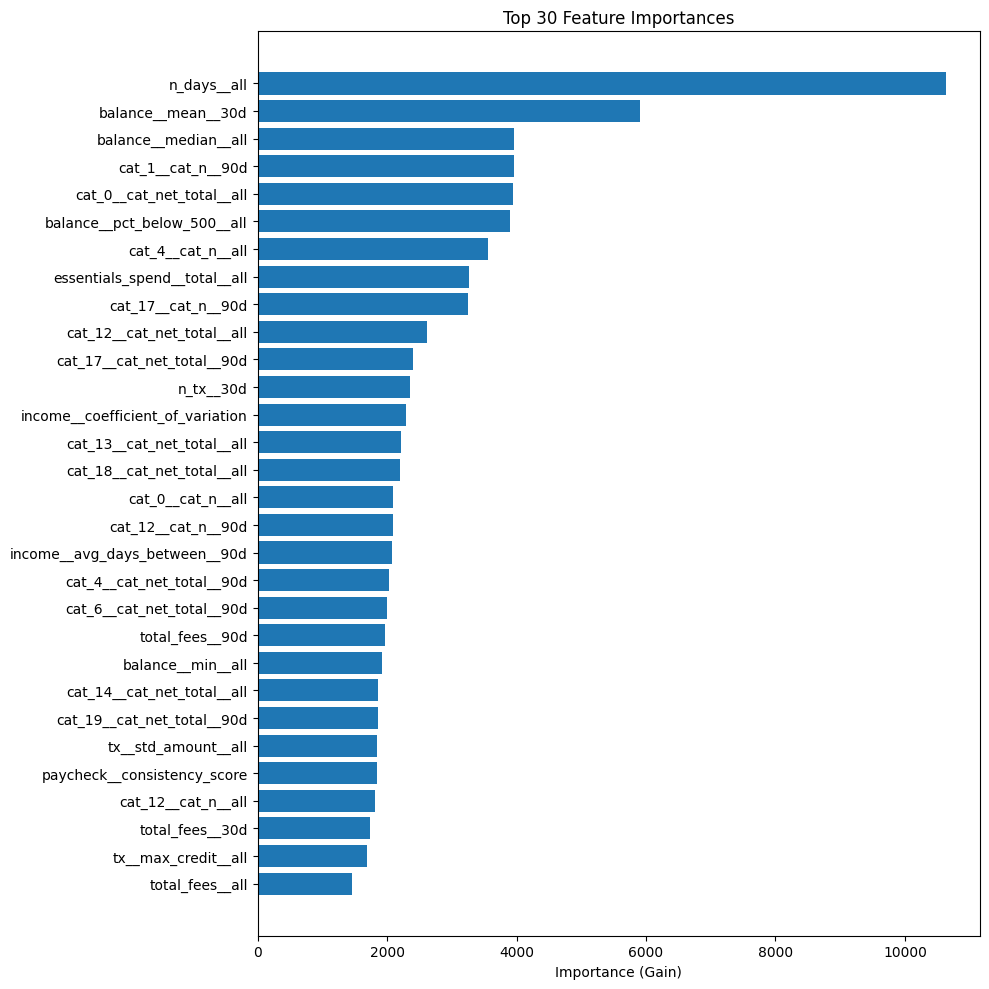

In [5]:
# Feature importance
importance = model.feature_importance(importance_type='gain')
feat_imp = pd.DataFrame({
    'feature': available_features,
    'importance': importance
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_n = min(30, len(feat_imp))
feat_imp_top = feat_imp.head(top_n)
ax.barh(range(top_n), feat_imp_top['importance'].values)
ax.set_yticks(range(top_n))
ax.set_yticklabels(feat_imp_top['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)')
ax.set_title(f'Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

## 5. Evaluation on All Splits

In [6]:
def evaluate(model, X, y_true, split_name):
    """Evaluate model and print metrics."""
    scoring_start = time.time()
    
    # Predict probabilities
    y_proba = model.predict(X, num_iteration=model.best_iteration)
    
    scoring_time = time.time() - scoring_start
    
    # AUC
    auc = roc_auc_score(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    
    # Binary predictions at 0.5 threshold
    y_pred = (y_proba >= 0.5).astype(int)
    
    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring Time: {scoring_time:.4f} seconds')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['No DQ', 'DQ']))
    print(f'Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    
    return y_proba, auc, ap, scoring_time

train_preds, train_auc, train_ap, train_time = evaluate(model, X_train, y_train, 'TRAIN')
val_preds, val_auc, val_ap, val_time = evaluate(model, X_val, y_val, 'VALIDATION')
test_preds, test_auc, test_ap, test_time = evaluate(model, X_test, y_test, 'TEST')


TRAIN Results
ROC-AUC: 0.9903
Average Precision: 0.8919
Scoring Time: 0.0044 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       1.00      0.90      0.95      5642
          DQ       0.49      1.00      0.66       548

    accuracy                           0.91      6190
   macro avg       0.74      0.95      0.80      6190
weighted avg       0.95      0.91      0.92      6190

Confusion Matrix:
[[5073  569]
 [   2  546]]

VALIDATION Results
ROC-AUC: 0.7829
Average Precision: 0.2461
Scoring Time: 0.0023 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.94      0.85      0.90      1880
          DQ       0.24      0.46      0.31       183

    accuracy                           0.82      2063
   macro avg       0.59      0.66      0.61      2063
weighted avg       0.88      0.82      0.84      2063

Confusion Matrix:
[[1607  273]
 [  98   85]]

TEST Results
ROC-AUC: 0.7789
A

## 6. Precision-Recall Curves

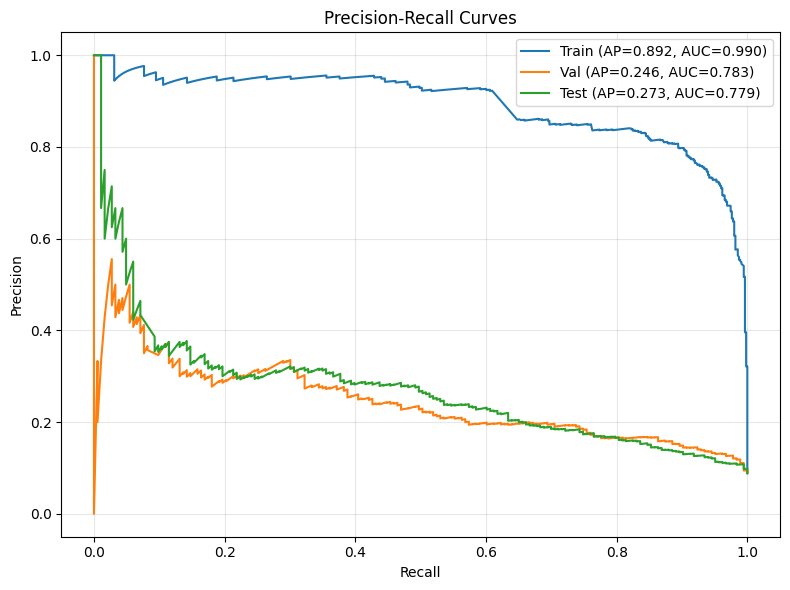

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_val in [
    (train_preds, y_train, 'Train', train_auc),
    (val_preds, y_val, 'Val', val_auc),
    (test_preds, y_test, 'Test', test_auc)
]:
    precision, recall, _ = precision_recall_curve(targets, preds)
    ap = average_precision_score(targets, preds)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f}, AUC={auc_val:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary

In [8]:
print('LightGBM Model Summary')
print('=' * 50)
print(f'Boosting type: GBDT')
print(f'Num leaves: {params["num_leaves"]}')
print(f'Learning rate: {params["learning_rate"]}')
print(f'Best iteration: {model.best_iteration}')
print(f'Features used: {len(available_features)}')
print(f'')
print(f'Training Time: {training_time:.2f}s ({training_time/60:.2f} min)')
print(f'')
print(f'{"Split":<12} {"ROC-AUC":<12} {"Avg Precision":<16} {"Scoring Time":<14}')
print(f'{"-"*54}')
print(f'{"Train":<12} {train_auc:<12.4f} {train_ap:<16.4f} {train_time:<14.4f}s')
print(f'{"Val":<12} {val_auc:<12.4f} {val_ap:<16.4f} {val_time:<14.4f}s')
print(f'{"Test":<12} {test_auc:<12.4f} {test_ap:<16.4f} {test_time:<14.4f}s')

LightGBM Model Summary
Boosting type: GBDT
Num leaves: 31
Learning rate: 0.05
Best iteration: 87
Features used: 50

Training Time: 1.12s (0.02 min)

Split        ROC-AUC      Avg Precision    Scoring Time  
------------------------------------------------------
Train        0.9903       0.8919           0.0044        s
Val          0.7829       0.2461           0.0023        s
Test         0.7789       0.2725           0.0015        s


---
# LightGBM – All Features

Same setup but using **every available feature** instead of the top-50 selection.

In [9]:
# ── Use ALL features (excluding target) ──────────────────────────
all_feature_cols = [c for c in features_df.columns if c != 'DQ_TARGET']

df_clean_all = features_df[features_df['DQ_TARGET'].notna()].copy()
y_all = df_clean_all['DQ_TARGET'].astype(int).values
X_all = df_clean_all[all_feature_cols].fillna(0).values

print(f'Total features: {len(all_feature_cols)}')
print(f'Samples: {X_all.shape[0]}')
print(f'Class distribution: 0={np.sum(y_all==0)}, 1={np.sum(y_all==1)}')

# Same 60/20/20 split
X_train_all, X_temp_all, y_train_all, y_temp_all = train_test_split(
    X_all, y_all, test_size=0.4, random_state=42, stratify=y_all
)
X_val_all, X_test_all, y_val_all, y_test_all = train_test_split(
    X_temp_all, y_temp_all, test_size=0.5, random_state=42, stratify=y_temp_all
)

print(f'\nTrain: {X_train_all.shape[0]} ({y_train_all.mean():.2%} positive)')
print(f'Val:   {X_val_all.shape[0]} ({y_val_all.mean():.2%} positive)')
print(f'Test:  {X_test_all.shape[0]} ({y_test_all.mean():.2%} positive)')

Total features: 216
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


In [10]:
# ── Train LightGBM (all features) ────────────────────────────────
n_neg_all = np.sum(y_train_all == 0)
n_pos_all = np.sum(y_train_all == 1)
scale_pos_weight_all = n_neg_all / n_pos_all
print(f'scale_pos_weight: {scale_pos_weight_all:.2f}')

train_data_all = lgb.Dataset(X_train_all, label=y_train_all, feature_name=all_feature_cols)
val_data_all   = lgb.Dataset(X_val_all,   label=y_val_all,   feature_name=all_feature_cols,
                              reference=train_data_all)

params_all = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight_all,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42,
}

print('\nTraining LightGBM (all features)...')
train_start_all = time.time()

model_all = lgb.train(
    params_all,
    train_data_all,
    num_boost_round=1000,
    valid_sets=[train_data_all, val_data_all],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

training_time_all = time.time() - train_start_all
print(f'\nTraining completed in {training_time_all:.2f}s')
print(f'Best iteration: {model_all.best_iteration}')
print(f'Best val AUC: {model_all.best_score["val"]["auc"]:.4f}')

scale_pos_weight: 10.30

Training LightGBM (all features)...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.985179	val's auc: 0.779114
[100]	train's auc: 0.997665	val's auc: 0.782714
Early stopping, best iteration is:
[82]	train's auc: 0.996002	val's auc: 0.783518

Training completed in 1.56s
Best iteration: 82
Best val AUC: 0.7835


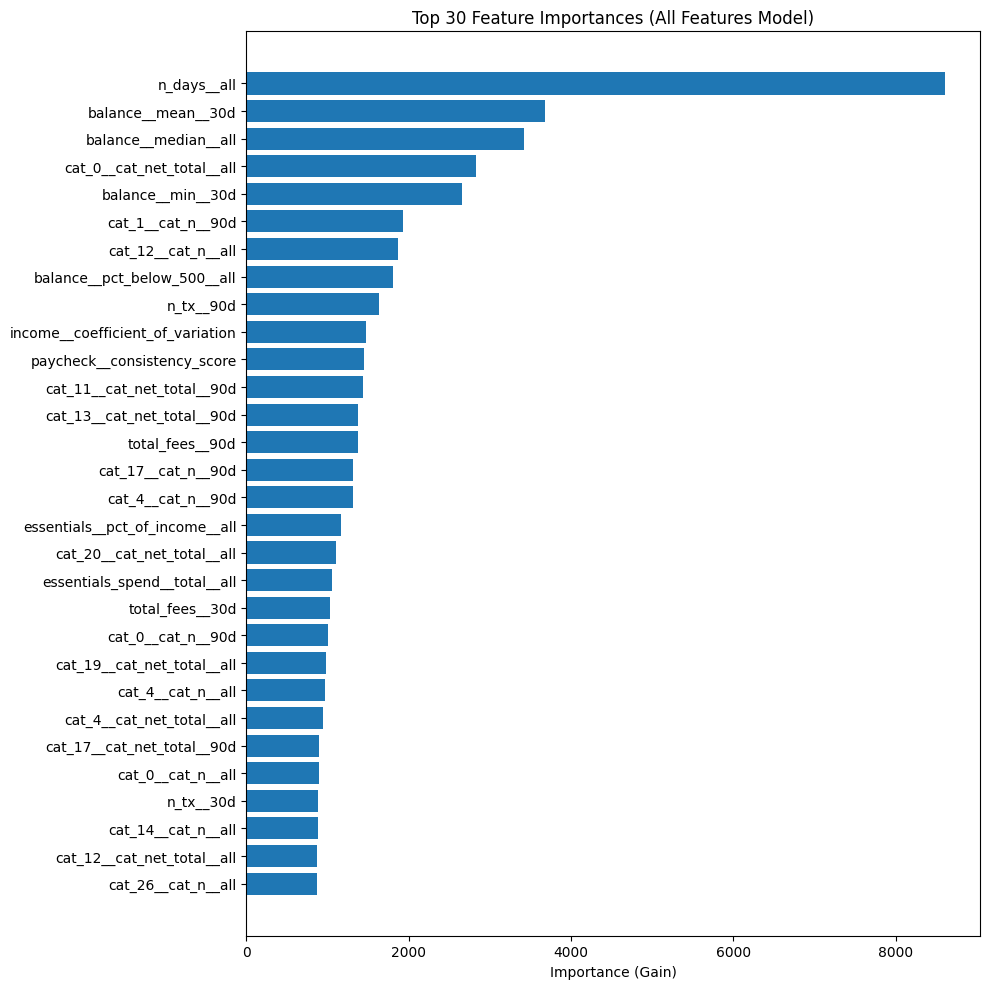

In [11]:
# ── Feature Importance (all features) ────────────────────────────
importance_all = model_all.feature_importance(importance_type='gain')
feat_imp_all = pd.DataFrame({
    'feature': all_feature_cols,
    'importance': importance_all
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_n_all = min(30, len(feat_imp_all))
feat_imp_top_all = feat_imp_all.head(top_n_all)
ax.barh(range(top_n_all), feat_imp_top_all['importance'].values)
ax.set_yticks(range(top_n_all))
ax.set_yticklabels(feat_imp_top_all['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)')
ax.set_title(f'Top {top_n_all} Feature Importances (All Features Model)')
plt.tight_layout()
plt.show()

In [12]:
# ── Evaluation (all features) ────────────────────────────────────
train_preds_all, train_auc_all, train_ap_all, train_time_all = evaluate(
    model_all, X_train_all, y_train_all, 'TRAIN (all features)')
val_preds_all, val_auc_all, val_ap_all, val_time_all = evaluate(
    model_all, X_val_all, y_val_all, 'VALIDATION (all features)')
test_preds_all, test_auc_all, test_ap_all, test_time_all = evaluate(
    model_all, X_test_all, y_test_all, 'TEST (all features)')


TRAIN (all features) Results
ROC-AUC: 0.9960
Average Precision: 0.9613
Scoring Time: 0.0064 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       1.00      0.91      0.95      5642
          DQ       0.53      1.00      0.69       548

    accuracy                           0.92      6190
   macro avg       0.76      0.95      0.82      6190
weighted avg       0.96      0.92      0.93      6190

Confusion Matrix:
[[5149  493]
 [   2  546]]

VALIDATION (all features) Results
ROC-AUC: 0.7835
Average Precision: 0.2511
Scoring Time: 0.0020 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.94      0.87      0.90      1880
          DQ       0.24      0.42      0.31       183

    accuracy                           0.83      2063
   macro avg       0.59      0.65      0.60      2063
weighted avg       0.88      0.83      0.85      2063

Confusion Matrix:
[[1636  244]
 [ 106   77]]



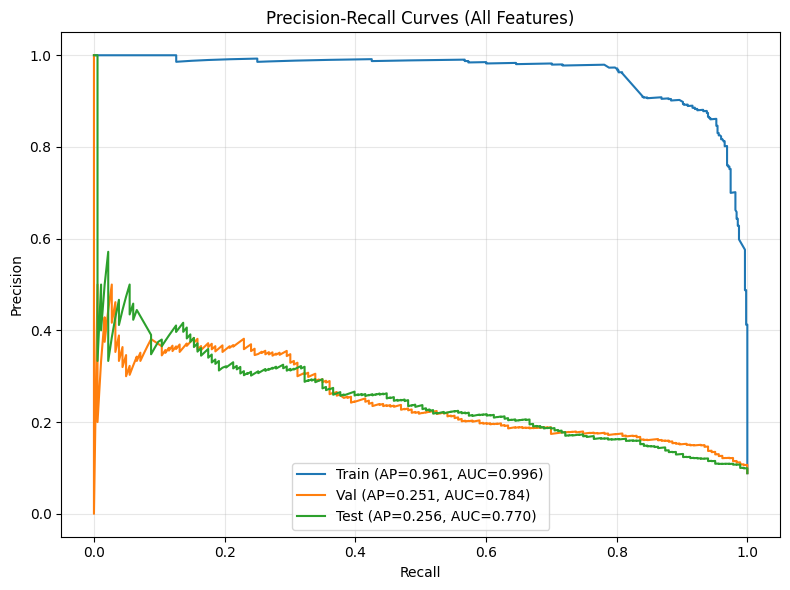

In [13]:
# ── Precision-Recall Curves (all features) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_v in [
    (train_preds_all, y_train_all, 'Train', train_auc_all),
    (val_preds_all,   y_val_all,   'Val',   val_auc_all),
    (test_preds_all,  y_test_all,  'Test',  test_auc_all),
]:
    prec, rec, _ = precision_recall_curve(targets, preds)
    ap_v = average_precision_score(targets, preds)
    ax.plot(rec, prec, label=f'{name} (AP={ap_v:.3f}, AUC={auc_v:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (All Features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# ── Summary: All Features vs Top-50 ──────────────────────────────
print('Comparison: Top-50 Features vs All Features')
print('=' * 70)
print(f'{"Metric":<22} {"Top-50":<22} {"All Features":<22}')
print(f'{"-"*66}')
print(f'{"Num features":<22} {len(available_features):<22} {len(all_feature_cols):<22}')
print(f'{"Best iteration":<22} {model.best_iteration:<22} {model_all.best_iteration:<22}')
print(f'{"Training time (s)":<22} {training_time:<22.2f} {training_time_all:<22.2f}')
print()
print(f'{"Split":<8} {"Metric":<16} {"Top-50":<14} {"All Features":<14}')
print(f'{"-"*52}')
for split, (auc50, ap50, t50, auca, apa, ta) in {
    'Train': (train_auc, train_ap, train_time, train_auc_all, train_ap_all, train_time_all),
    'Val':   (val_auc,   val_ap,   val_time,   val_auc_all,   val_ap_all,   val_time_all),
    'Test':  (test_auc,  test_ap,  test_time,  test_auc_all,  test_ap_all,  test_time_all),
}.items():
    print(f'{split:<8} {"ROC-AUC":<16} {auc50:<14.4f} {auca:<14.4f}')
    print(f'{"":8} {"Avg Precision":<16} {ap50:<14.4f} {apa:<14.4f}')
    print(f'{"":8} {"Score time (s)":<16} {t50:<14.4f} {ta:<14.4f}')

Comparison: Top-50 Features vs All Features
Metric                 Top-50                 All Features          
------------------------------------------------------------------
Num features           50                     216                   
Best iteration         87                     82                    
Training time (s)      1.12                   1.56                  

Split    Metric           Top-50         All Features  
----------------------------------------------------
Train    ROC-AUC          0.9903         0.9960        
         Avg Precision    0.8919         0.9613        
         Score time (s)   0.0044         0.0064        
Val      ROC-AUC          0.7829         0.7835        
         Avg Precision    0.2461         0.2511        
         Score time (s)   0.0023         0.0020        
Test     ROC-AUC          0.7789         0.7696        
         Avg Precision    0.2725         0.2557        
         Score time (s)   0.0015         0.0026        